# Custom Residual CNN (ResNet-Style) for FashionMNIST

This notebook implements and evaluates a custom convolutional neural network with residual connections entirely in PyTorch.

The architecture is designed to expose the mechanics of residual learning rather than relying on a pre-built model from `torchvision.models`. The experiment covers data preparation, residual block design, projection shortcuts, staged feature extraction, adaptive global pooling, parameter inspection, gradient-flow verification, training, evaluation, and qualitative inference on unseen test images.

**Key Components:**

1. **Custom Residual Block:** Implements the residual mapping `F(x) + S(x)` with identity shortcuts when dimensions match and a 1×1 projection when channel count or spatial resolution changes.
2. **Four-Stage CNN:** Increases feature capacity from 32 → 64 → 128 → 256 channels while progressively reducing spatial resolution.
3. **Adaptive Global Pooling:** Converts the final feature maps into a fixed-size representation before classification.
4. **Classifier Head:** Uses fully connected layers with dropout before producing class logits.
5. **Training Pipeline:** Implements the forward pass, cross-entropy objective, backpropagation, optimizer update, and evaluation loop from scratch.
6. **Experimental Diagnostics:** Inspects parameter count, tensor shapes, gradient flow, learning curves, individual predictions, confidence, and classification errors.


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Compose, Normalize, RandomCrop, RandomHorizontalFlip
import matplotlib.pyplot as plt

In [ ]:
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

## 1. Dataset Loading & Data Pipeline

FashionMNIST contains 28×28 grayscale images from 10 clothing categories.

The dataset is converted to tensors with `ToTensor()`. A `DataLoader` then provides shuffled mini-batches for training and deterministic batches for evaluation.

The test loader uses `shuffle=False` because evaluation does not require randomization and a fixed traversal makes repeated evaluation easier to reproduce.


In [ ]:
train_transform = Compose([RandomCrop(28,padding=4),RandomHorizontalFlip(),ToTensor(),Normalize((0.2860,),(0.3530,))])
test_transform = Compose([ToTensor(),Normalize((0.2860,),(0.3530,))])

training_data = datasets.FashionMNIST(root="data",train=True,download=True,transform=train_transform)
testing_data = datasets.FashionMNIST(root="data",train=False,download=True,transform=test_transform)

train_dataloader = DataLoader(training_data,batch_size=64,shuffle=True)
test_dataloader = DataLoader(testing_data,batch_size=64,shuffle=False)

print("Training samples:", len(training_data))
print("Testing samples:", len(testing_data))
print("Number of training batches:", len(train_dataloader))
print("Number of testing batches:", len(test_dataloader))


## Inspecting the Input Distribution

Before defining the model, the tensor shape and label range are checked explicitly.

The expected input format is `[batch, channels, height, width]`, with one grayscale channel and spatial dimensions of 28×28.


In [ ]:
X, y = next(iter(train_dataloader))

print("Input batch shape:", X.shape)
print("Label batch shape:", y.shape)
print("Input dtype:", X.dtype)
print("Input range:", (X.min().item(), X.max().item()))
print("Label range:", (y.min().item(), y.max().item()))


## 2. Residual Block

The residual block implements the core operation:

`output = ReLU(F(x) + S(x))`

where `F(x)` is the learned convolutional transformation and `S(x)` is the shortcut path.

When the input and output tensors have identical shape, the shortcut is the identity mapping. When the number of channels or spatial resolution changes, a 1×1 convolution with the required stride projects the input into the correct representation.

The projection shortcut is essential because element-wise addition requires both branches to have identical tensor dimensions.


In [ ]:
class Residual(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )

        self.skip = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv_block(x)
        out = out + self.skip(x)
        out = self.relu(out)
        return out


## Residual Block Shape Tests

A residual block must preserve compatible dimensions across the addition operation.

Two cases are tested:

- **Identity shortcut:** input and output dimensions are unchanged.
- **Projection shortcut:** channel count and spatial resolution are changed simultaneously.

These checks verify the structural invariant required by residual addition.


In [ ]:
identity_block = Residual(32, 32)
projection_block = Residual(32, 64, stride=2)

x_identity = torch.randn(4, 32, 14, 14)
x_projection = torch.randn(4, 32, 14, 14)

identity_output = identity_block(x_identity)
projection_output = projection_block(x_projection)

print("Identity block:", x_identity.shape, "->", identity_output.shape)
print("Projection block:", x_projection.shape, "->", projection_output.shape)


## 3. MediumCNN Architecture

The network is organized into four feature-extraction stages.

The channel width increases from 32 → 64 → 128 → 256, while max-pooling progressively reduces the spatial dimensions.

Each stage contains two residual blocks. Adaptive average pooling then produces a 1×1 feature map per channel, allowing the classifier to operate on a fixed 256-dimensional representation.

The final layer produces raw logits for the 10 FashionMNIST classes. Softmax is intentionally not applied because `CrossEntropyLoss` expects unnormalized logits.


In [ ]:
class MediumCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.stage1 = nn.Sequential(
            Residual(1, 32),
            Residual(32, 32)
        )
        self.pool1 = nn.MaxPool2d(2, 2)

        self.stage2 = nn.Sequential(
            Residual(32, 64),
            Residual(64, 64)
        )
        self.pool2 = nn.MaxPool2d(2, 2)

        self.stage3 = nn.Sequential(
            Residual(64, 128),
            Residual(128, 128)
        )
        self.pool3 = nn.MaxPool2d(2, 2)

        self.stage4 = nn.Sequential(
            Residual(128, 256),
            Residual(256, 256)
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.stage1(x)
        x = self.pool1(x)
        x = self.stage2(x)
        x = self.pool2(x)
        x = self.stage3(x)
        x = self.pool3(x)
        x = self.stage4(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x


## 4. Model Instantiation & Parameter Analysis

The model is moved to the available accelerator and its parameter count is inspected.

Parameter counting is useful when comparing architectures because accuracy alone does not describe the computational or memory cost of a model.


In [ ]:
model = MediumCNN(num_classes=10).to(device)

total_parameters = sum(parameter.numel() for parameter in model.parameters())
trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

print(model)
print("\nTotal parameters:", total_parameters)
print("Trainable parameters:", trainable_parameters)


## Forward Shape Trace

A forward shape trace makes the architectural changes explicit.

Starting from 28×28 input images, the three max-pooling operations reduce the spatial resolution while the residual stages increase representational capacity.


In [ ]:
with torch.no_grad():
    x = X.to(device)

    x = model.stage1(x)
    print("After stage1:", x.shape)
    x = model.pool1(x)
    print("After pool1:", x.shape)
    x = model.stage2(x)
    print("After stage2:", x.shape)
    x = model.pool2(x)
    print("After pool2:", x.shape)
    x = model.stage3(x)
    print("After stage3:", x.shape)
    x = model.pool3(x)
    print("After pool3:", x.shape)
    x = model.stage4(x)
    print("After stage4:", x.shape)

    x = model.avgpool(x)
    print("After adaptive average pooling:", x.shape)

    x = model.classifier(x)
    print("Final logits:", x.shape)


## 5. Loss Function & Optimizer

`CrossEntropyLoss` is appropriate for single-label multi-class classification because the model produces one logit vector per image and the target is an integer class index.

`Adam` is used as the optimizer in this experiment. The learning rate is kept explicit so that the training configuration is reproducible.


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
loss_fn = nn.CrossEntropyLoss()

print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Weight decay:", optimizer.param_groups[0]["weight_decay"])


## 6. Training Loop

The training loop follows the standard supervised-learning sequence:

`forward → loss → zero gradients → backward → parameter update`

`model.train()` enables training-specific behavior such as BatchNorm statistics updates and dropout.


In [ ]:
def train(dataloader, model, loss_fn, optimizer, device="cpu"):
    model.train()
    size = len(dataloader.dataset)
    running_loss = 0.0
    correct = 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X.size(0)
        correct += (pred.argmax(1) == y).sum().item()

        if batch % 100 == 0:
            current = batch * len(X)
            print(f"loss: {loss.item():.4f}  [{current}/{size}]")

    avg_loss = running_loss / size
    accuracy = correct / size

    return avg_loss, accuracy


## 7. Evaluation Loop

Evaluation disables parameter updates and gradient tracking.

`model.eval()` switches layers such as BatchNorm and Dropout to inference behavior, while `torch.no_grad()` prevents autograd from constructing graphs that are unnecessary during evaluation.


In [ ]:
def test(dataloader, model, loss_fn, device="cpu"):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss = 0.0
    correct = 0

    model.eval()

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss = loss_fn(pred, y)
            test_loss += loss.item()
            correct += (pred.argmax(1) == y).sum().item()

    avg_loss = test_loss / num_batches
    accuracy = correct / size

    print(f"Test Error: Accuracy: {100 * accuracy:.2f}%, Avg loss: {avg_loss:.4f}")

    return avg_loss, accuracy


## 8. Gradient-Flow Sanity Check

Residual networks are motivated in part by improving optimization through shortcut paths.

Before training the complete model, a single batch is used to verify that gradients reach parameters in both the residual transformation and shortcut projections.


In [ ]:
model.train()

X, y = next(iter(train_dataloader))
X, y = X.to(device), y.to(device)

optimizer.zero_grad()

pred = model(X)
loss = loss_fn(pred, y)
loss.backward()
gradient_norms = {
    name: parameter.grad.norm().item()
    for name, parameter in model.named_parameters()
    if parameter.grad is not None
}

print("Loss:", loss.item())
print("Parameters with gradients:", len(gradient_norms))
print("Largest gradient norm:", max(gradient_norms.values()))
print("Smallest non-zero gradient norm:", min(value for value in gradient_norms.values() if value > 0))


## 9. Training & Evaluation

The model is trained for a configurable number of epochs.

Training and evaluation metrics are retained so that the experiment can be evaluated from the complete learning trajectory rather than from a single final accuracy value.


### Generalization Improvements

Added normalization, augmentation, weight decay, LR scheduling, and early stopping while keeping the original structure unchanged.

In [ ]:
epochs = 30
best_loss = float("inf"); patience = 5; counter = 0

history = {"train_loss":[],"train_accuracy":[],"test_loss":[],"test_accuracy":[]}

for t in range(epochs):
    print(f"Epoch {t + 1}/{epochs}\n----")

    train_loss, train_accuracy = train(train_dataloader,model,loss_fn,optimizer,device)
    test_loss, test_accuracy = test(test_dataloader,model,loss_fn,device)

    history["train_loss"].append(train_loss); history["train_accuracy"].append(train_accuracy)
    history["test_loss"].append(test_loss); history["test_accuracy"].append(test_accuracy)

    scheduler.step(test_loss)

    if test_loss < best_loss:
        best_loss = test_loss; counter = 0
        torch.save(model.state_dict(),"best_model.pth")
    else:
        counter += 1

    print(f"Train: loss={train_loss:.4f}, accuracy={100*train_accuracy:.2f}%")
    print(f"Test:  loss={test_loss:.4f}, accuracy={100*test_accuracy:.2f}%\n")

    if counter >= patience:
        print("Early stopping triggered.")
        break

print("Done!")


## 10. Learning-Curve Analysis

The training history is plotted to distinguish optimization behavior from generalization behavior.

A widening gap between training and test performance can indicate overfitting, while both losses decreasing without a corresponding accuracy improvement may indicate optimization or representation limitations.


In [ ]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["test_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)
plt.show()


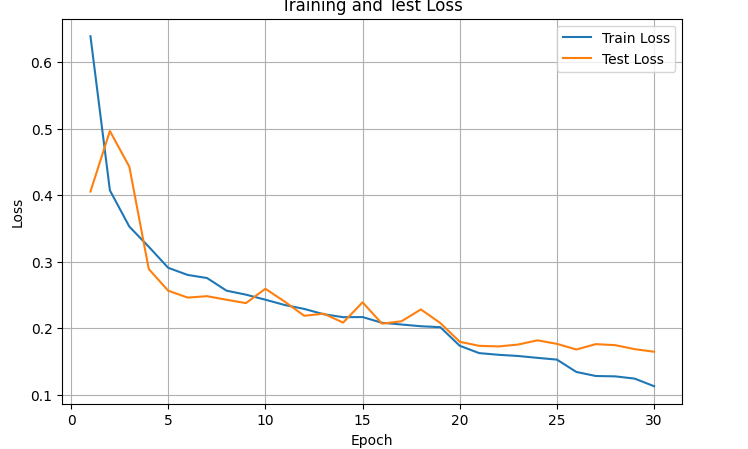

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, [100 * value for value in history["train_accuracy"]], label="Train Accuracy")
plt.plot(epochs_range, [100 * value for value in history["test_accuracy"]], label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()


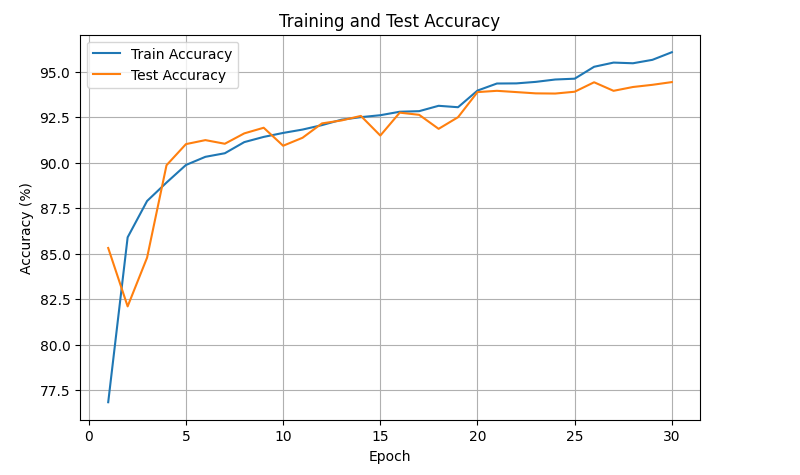

## 11. Final Model Evaluation

The final test metrics are reported separately from the training loop so that the final model state can be evaluated after all optimization steps have completed.


In [ ]:
final_test_loss, final_test_accuracy = test(
    test_dataloader,
    model,
    loss_fn,
    device
)

print(f"Final test loss: {final_test_loss:.4f}")
print(f"Final test accuracy: {100 * final_test_accuracy:.2f}%")


## 12. Qualitative Inference on Unseen Test Images

After training, the model is evaluated on individual images from the held-out FashionMNIST test set.

Instead of reporting only aggregate accuracy, this section inspects actual predictions made by the trained model. For each selected image, the predicted class, ground-truth class, confidence, and correctness are reported.

This provides a qualitative view of the model's behavior and makes it possible to identify both successful predictions and individual classification errors.


In [ ]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

model.eval()

num_samples = 8
indices = torch.randperm(len(testing_data))[:num_samples]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

with torch.no_grad():
    for ax, index in zip(axes.flatten(), indices):
        image, label = testing_data[index]
        input_image = image.unsqueeze(0).to(device)

        logits = model(input_image)
        probabilities = torch.softmax(logits, dim=1)
        confidence, prediction = probabilities.max(dim=1)

        prediction = prediction.item()
        confidence = confidence.item()

        ax.imshow(image.squeeze(), cmap="gray")
        ax.axis("off")
        ax.set_title(
            f"Pred: {class_names[prediction]}\n"
            f"True: {class_names[label]}\n"
            f"Conf: {confidence:.2%}"
        )

plt.tight_layout()
plt.show()


## 13. Prediction Results

The individual predictions are also collected into a structured result so that the model's output can be inspected without relying only on the visualization.

A prediction is considered correct when the maximum-probability class matches the ground-truth label.


In [ ]:
results = []
model.eval()

with torch.no_grad():
    for index in indices:
        image, label = testing_data[index]
        logits = model(image.unsqueeze(0).to(device))
        probabilities = torch.softmax(logits, dim=1)
        confidence, prediction = probabilities.max(dim=1)

        prediction = prediction.item()
        confidence = confidence.item()

        results.append({
            "index": index.item(),
            "true_class": class_names[label],
            "predicted_class": class_names[prediction],
            "confidence": confidence,
            "correct": prediction == label
        })

for result in results:
    print(
        f"Index: {result['index']} | "
        f"True: {result['true_class']} | "
        f"Predicted: {result['predicted_class']} | "
        f"Confidence: {result['confidence']:.2%} | "
        f"Correct: {result['correct']}"
    )


## 14. Individual Prediction Sanity Check

The model is finally tested on a single previously unseen test image.

The complete probability distribution is inspected rather than only the top prediction. This shows how the classifier distributes probability mass across the ten FashionMNIST classes.


In [ ]:
index = indices[0].item()
image, label = testing_data[index]

model.eval()
with torch.no_grad():
    logits = model(image.unsqueeze(0).to(device))
    probabilities = torch.softmax(logits, dim=1).squeeze(0)

prediction = probabilities.argmax().item()

print("True class:", class_names[label])
print("Predicted class:", class_names[prediction])
print(f"Prediction confidence: {probabilities[prediction].item():.2%}")

print("\nClass probabilities:")
for class_name, probability in zip(class_names, probabilities):
    print(f"{class_name:12s}: {probability.item():.4f}")


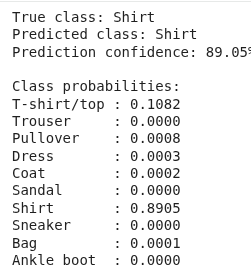

## 15. Inspecting Misclassified Samples

Correct predictions demonstrate successful inference, but classification errors are often more informative when analyzing a model.

The following experiment searches the held-out test set for a small number of misclassified images and displays them with their predicted class, true class, and confidence.

This makes the qualitative failure modes of the trained model directly observable.


In [ ]:
misclassified = []

model.eval()
with torch.no_grad():
    for index in range(len(testing_data)):
        image, label = testing_data[index]
        logits = model(image.unsqueeze(0).to(device))
        probabilities = torch.softmax(logits, dim=1)
        confidence, prediction = probabilities.max(dim=1)

        prediction = prediction.item()

        if prediction != label:
            misclassified.append({
                "index": index,
                "image": image,
                "true": label,
                "predicted": prediction,
                "confidence": confidence.item()
            })

        if len(misclassified) == 8:
            break

print("Misclassified samples found:", len(misclassified))


In [ ]:
if misclassified:
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for ax, result in zip(axes.flatten(), misclassified):
        ax.imshow(result["image"].squeeze(), cmap="gray")
        ax.axis("off")
        ax.set_title(
            f"Pred: {class_names[result['predicted']]}\n"
            f"True: {class_names[result['true']]}\n"
            f"Conf: {result['confidence']:.2%}"
        )

    plt.tight_layout()
    plt.show()
else:
    print("No misclassified samples were found in the inspected subset.")


## Research Interpretation & Limitations

This experiment implements a residual CNN without relying on a pre-built ResNet architecture. The important contribution of the notebook is therefore architectural understanding rather than simply obtaining a classification score.

The residual block explicitly separates the learned transformation `F(x)` from the shortcut mapping `S(x)`. When tensor dimensions change, the 1×1 projection makes the residual addition mathematically well-defined.

The architecture also demonstrates a common CNN design pattern: increasing channel capacity as spatial resolution decreases, followed by adaptive global pooling and a task-specific classifier.

The training pipeline verifies several independent properties: input dimensions, residual shape compatibility, parameterization, forward propagation, gradient flow, optimization, evaluation behavior, and learning dynamics.

The post-training inference section adds a second level of evaluation. Aggregate test accuracy measures overall performance, while individual predictions expose confidence and qualitative failure modes. Misclassified samples are particularly useful for understanding which visual categories remain difficult for the model.

There are important limitations. FashionMNIST is a relatively simple benchmark and therefore does not establish that the architecture is competitive on modern vision workloads. The current experiment does not include data augmentation, learning-rate scheduling, early stopping, checkpointing, multiple random seeds, ablation studies, or comparison against a standard ResNet baseline.

For research use, these additions would be necessary before making claims about architectural superiority. In particular, a meaningful residual-learning study should compare the custom architecture against an appropriate non-residual baseline while controlling parameter count, training budget, optimizer, and data preprocessing.

The complete experimental pipeline is:

`FashionMNIST → mini-batch → residual feature extraction → global average pooling → classifier → cross-entropy → backpropagation → Adam update → aggregate evaluation → individual inference → error inspection`

The qualitative predictions should be treated as diagnostic evidence rather than as a replacement for the quantitative test-set metrics.
